In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
class LinearRegressionGD:
    
    def __init__(self, learning_rate, n_iters):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0   
        self.theta_1 = 0  
        self.sse_history = []
    
    def fit(self, X, y):
        n = len(X)
        
        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y
            d_theta_0 = (2/n) * np.sum(error)
            d_theta_1 = (2/n) * np.sum(error * X)
            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1
            sse = np.sum(error ** 2)
            self.sse_history.append(sse)
    
    def predict(self, X):
        return self.theta_0 + self.theta_1 * X
    
    def mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)
    
    def plot_training(self, X, y):
        plt.figure()
        plt.plot(range(self.n_iters), self.sse_history)
        plt.xlabel("Iterations")
        plt.ylabel("SSE")
        plt.title("SSE vs Iterations")
        plt.show()
        
        plt.figure()
        plt.scatter(X, y)
        y_line = self.predict(X)
        plt.plot(X, y_line)
        plt.xlabel("House Size")
        plt.ylabel("Price (thousands)")
        plt.title("Regression Line")
        plt.show()

theta_0: -1.0055957901462392e+95
theta_1: -7.326427288635144e+96
Prediction for 70m²: [-5.1295047e+98]


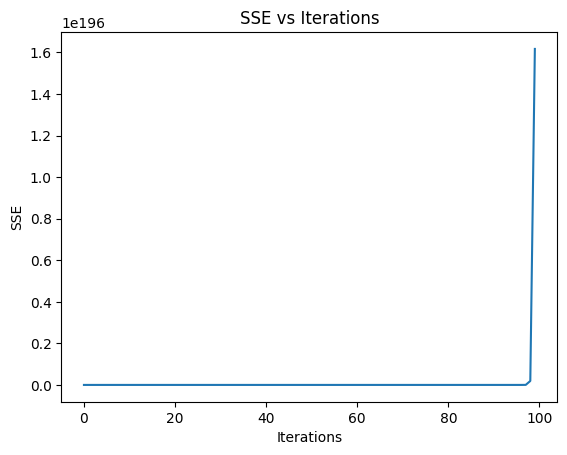

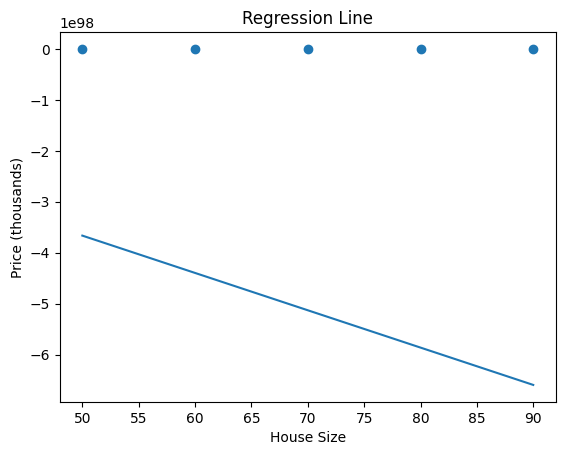

In [16]:
X = np.array([50, 60, 70, 80, 90]) 
y = np.array([150, 180, 210, 240, 270]) 

model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(X, y)

print("theta_0:", model.theta_0) 
print("theta_1:", model.theta_1)

prediction = model.predict(np.array([70]))
print("Prediction for 70m²:", prediction)
model.plot_training(X, y)

In [ ]:
#X represents house size
#Y represents house price
#theta 0 represents the intercept with y-axis
#theta 1 represents the slope of the line
#The prediction with learning rate(0.001) is not reasonble because there is no negative prices and this happened because the learning rate is too high 
#Generaly SSE decreases over time because after each iteration the y_pred gets closer to y and the difference between them (error) gets smaller but here the SSE increases over time because after each iteration the y_pred gets farther from y and the difference between them (error) gets bigger
#Covergence means the model found the best linne that fits the data

theta_0: -2.7553577959884946e+299
theta_1: -2.007459532378114e+301
Prediction for 70m²: [-1.40549721e+303]


C:\Users\NOTEBOOK\AppData\Local\Temp\ipykernel_16240\3773511058.py:20: RuntimeWarning: overflow encountered in square
  sse = np.sum(error ** 2)


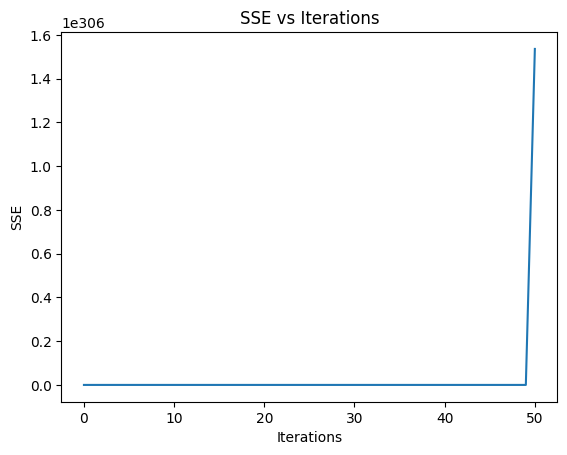

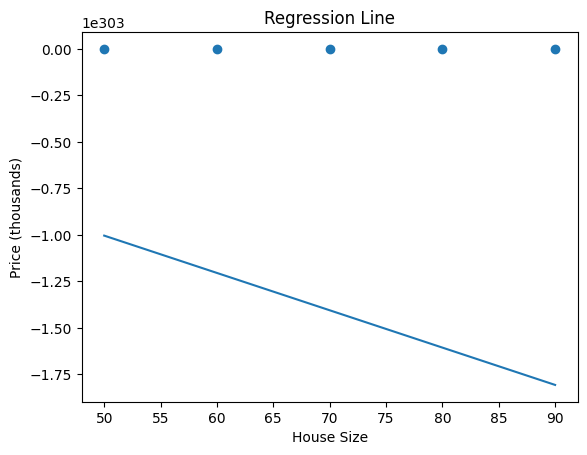

In [ ]:
#Training the model with very large learnig rate
X = np.array([50, 60, 70, 80, 90]) 
y = np.array([150, 180, 210, 240, 270]) 

model = LinearRegressionGD(learning_rate=0.1, n_iters=100)
model.fit(X, y)

print("theta_0:", model.theta_0) 
print("theta_1:", model.theta_1)

prediction = model.predict(np.array([70]))
print("Prediction for 70m²:", prediction)
model.plot_training(X, y)
#SSE increases over time because after each iteration the y_pred gets farther from y and the difference between them (error) gets bigger
#The model is not working propely
#Convergence speed is too fast

theta_0: 0.04116492950170943
theta_1: 2.9993713328364127
Prediction for 70m²: [209.99715823]


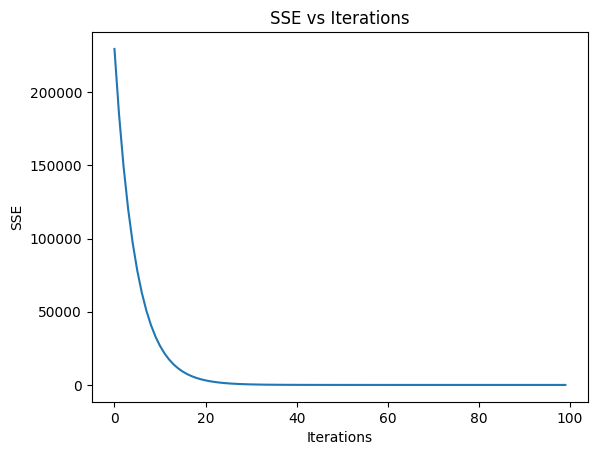

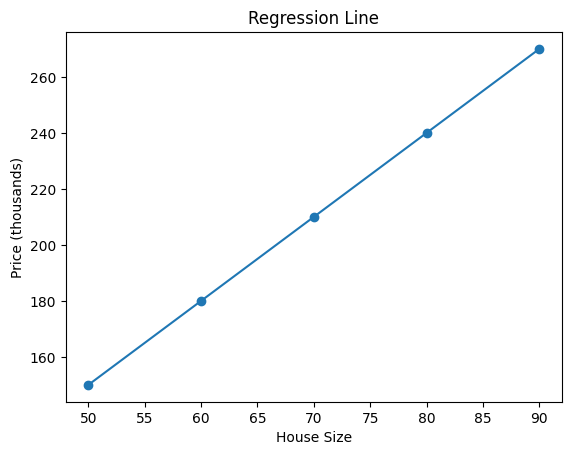

In [ ]:
#Traning the model with very small learnig rate
X = np.array([50, 60, 70, 80, 90]) 
y = np.array([150, 180, 210, 240, 270]) 

model = LinearRegressionGD(learning_rate=0.00001, n_iters=100)
model.fit(X, y)

print("theta_0:", model.theta_0) 
print("theta_1:", model.theta_1)

prediction = model.predict(np.array([70]))
print("Prediction for 70m²:", prediction)
model.plot_training(X, y)
#SSE decreases over time because after each iteration the y_pred gets closer to y but the difference between them (error) gets smaller
#The model is working propely
#Convergence speed is optimal